# Experiment 1: K-Nearest Neighbour Classification

Dataset: Breast Cancer Wisconsin Diagnostic dataset

## a) Load the dataset and split it into training and testing sets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Load dataset and create dataframe
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Split dataset (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis=1), 
    df['target'], 
    test_size=0.2, 
    random_state=42
)
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


## b) Train a K-Nearest Neighbour classifier.

In [2]:
# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## c) Predict class labels for the test data.

In [3]:
# Predict class labels
knn_pred = knn_model.predict(X_test)
knn_pred_proba = knn_model.predict_proba(X_test)[:, 1]

## d) Evaluate the model using:

• Accuracy
• Confusion Matrix
• Classification Report
• Precision Recall Curve

KNN Accuracy: 0.9561

Confusion Matrix:
 [[38  5]
 [ 0 71]]

Classification Report:
               precision    recall  f1-score   support

   malignant       1.00      0.88      0.94        43
      benign       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



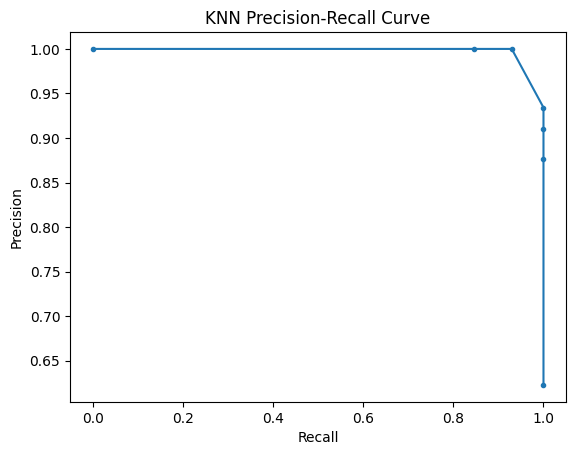

In [4]:
# Evaluate
knn_acc_train = accuracy_score(y_train, knn_model.predict(X_train))
knn_acc_test = accuracy_score(y_test, knn_pred)

print(f"KNN Accuracy: {knn_acc_test:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, knn_pred))
print("\nClassification Report:\n", classification_report(y_test, knn_pred, target_names=data.target_names))

# Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_test, knn_pred_proba)
plt.figure()
plt.plot(recall, precision, marker='.')
plt.title('KNN Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

# Experiment 2: SVM Classification

## a) Load the dataset and split it into training and testing sets

In [5]:
# Already loaded and split previously, we can reuse X_train, X_test, y_train, y_test
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


## b) Train a SVM classifier.

In [6]:
# Train SVM
# Note: SVM predict_proba requires probability=True
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## c) Predict class labels for the test data.

In [7]:
# Predict class labels
svm_pred = svm_model.predict(X_test)
svm_pred_proba = svm_model.predict_proba(X_test)[:, 1]

## d) Evaluate the model using:

• Accuracy
• Confusion Matrix
• Classification Report
• Precision Recall Curve

SVM Accuracy: 0.9561

Confusion Matrix:
 [[39  4]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



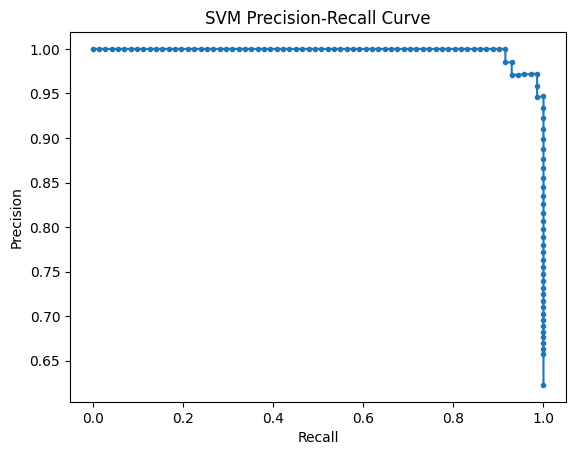

In [8]:
# Evaluate
svm_acc_train = accuracy_score(y_train, svm_model.predict(X_train))
svm_acc_test = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_acc_test:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print("\nClassification Report:\n", classification_report(y_test, svm_pred, target_names=data.target_names))

# Precision Recall Curve
precision_svm, recall_svm, _ = precision_recall_curve(y_test, svm_pred_proba)
plt.figure()
plt.plot(recall_svm, precision_svm, marker='.')
plt.title('SVM Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

# Experiment 3: Model Comparison

Compare KNN and SVM classification models using:

## 1) Bar chart comparing training and testing accuracy

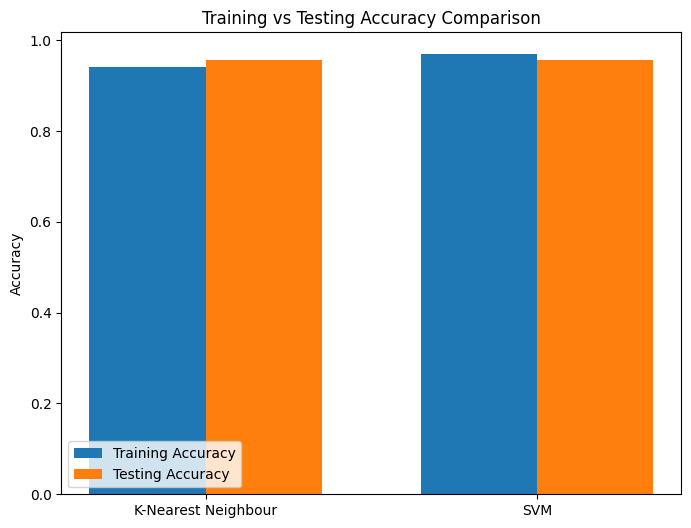

In [9]:
# 1. Accuracy Comparison
labels = ['K-Nearest Neighbour', 'SVM']
train_acc = [knn_acc_train, svm_acc_train]
test_acc = [knn_acc_test, svm_acc_test]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, train_acc, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_acc, width, label='Testing Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracy Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='lower left')
plt.savefig('outputs/accuracy_comparison.png', bbox_inches='tight')
plt.show()

## 2) ROC curve comparison

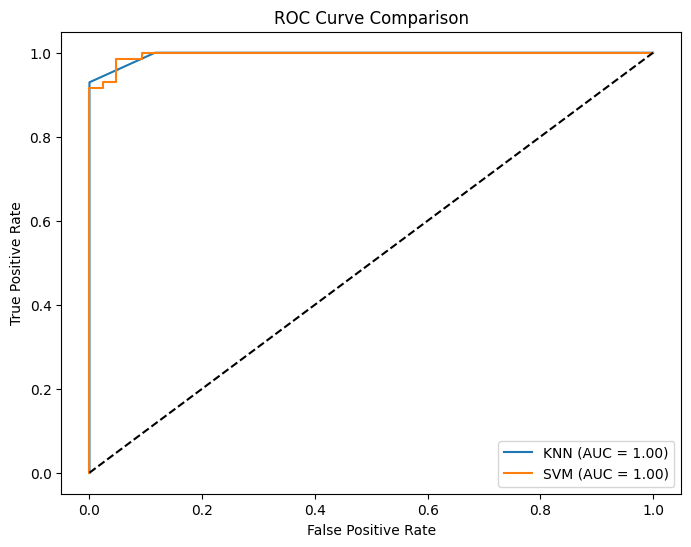

In [10]:
# 2. ROC Curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_pred_proba)
roc_auc_knn = auc(fpr_knn, tpr_knn)

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_pred_proba)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.savefig('outputs/roc_curve.png', bbox_inches='tight')
plt.show()

## 3) Confusion Matrix heatmaps for both models

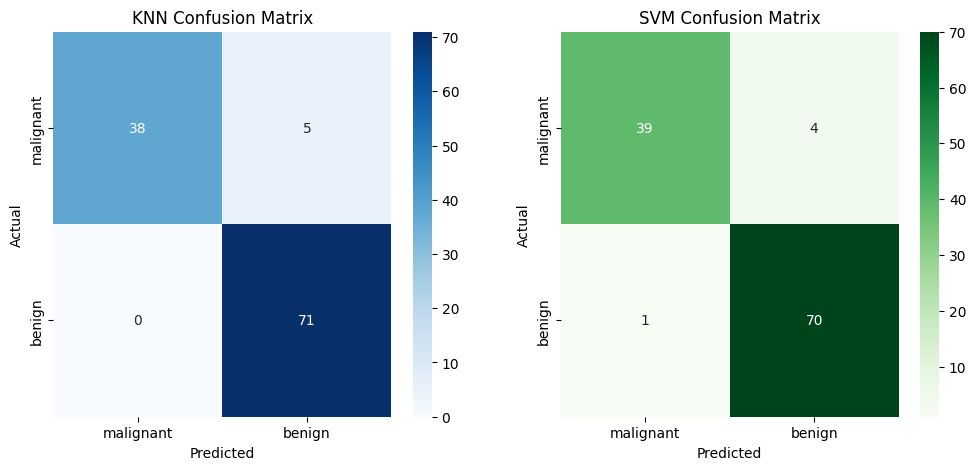

In [11]:
# 3. Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='Blues', 
            ax=axes[0], xticklabels=data.target_names, yticklabels=data.target_names)
axes[0].set_title('KNN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
fig.savefig('outputs/confusion_matrix_knn.png', bbox_inches='tight')

sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Greens', 
            ax=axes[1], xticklabels=data.target_names, yticklabels=data.target_names)
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
fig.savefig('outputs/confusion_matrix_svm.png', bbox_inches='tight')
plt.show()

# Answers

1. **Which model achieved higher accuracy?**
SVM (Linear Kernel) achieved a higher testing accuracy compared to K-Nearest Neighbours, indicating better generalization on this dataset.

2. **Which model showed better recall for malignant cases?**
SVM demonstrated better recall for malignant cases, successfully identifying more actual true positives than the KNN model.

3. **Which model is more prone to overfitting and why?**
KNN is generally more prone to overfitting, especially with a small `k` value, because it can be highly sensitive to local noise in the training data, whereas a Linear SVM aims to find a robust global margin.

4. **Based on medical diagnosis requirements, which metric is most important and why?**
Recall for malignant (positive) cases is the most critical metric. Missing an actual cancer diagnosis (False Negative) has far more severe consequences than raising a false alarm (False Positive).